In [21]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [22]:
G=nx.Graph()

In [23]:
#raw node
G.add_node("A",messages=5)
G.add_node("B",messages=2)
G.add_edge("A","B",weights=1.0)

In [24]:
def fuzzyify_node(messages,max_message=10):
    T=min(messages/max_message,1.0)
    I=1-abs(0.5-T)
    F=1-T

    return np.array([T,I,F])

In [25]:
T=min(10/2,1.0)
I=1-abs(0.5-T)

F=1-T
print(T,I,F)

1.0 0.5 0.0


In [40]:
for node in G.nodes():
    G.nodes[node]['NV']=fuzzyify_node(G.nodes[node]['messages'])
    print(G.nodes[node]['NV'])

[0.5 1.  0.5]
[0.2 0.7 0.8]


{'A': Text(-1.0, 0.08874330061979659, '[0.5 1.  0.5]'),
 'B': Text(1.0, -0.08874330061979667, '[0.2 0.7 0.8]')}

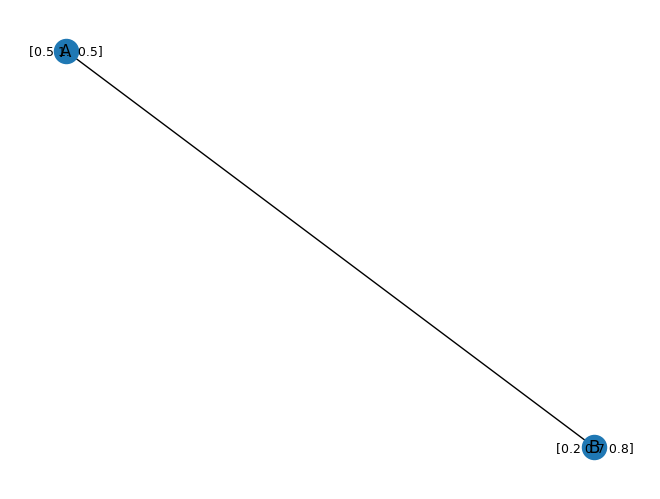

In [39]:
pos=nx.spring_layout(G)
nx.draw(G,pos,with_labels=True)
feature_labels = {
    node: f"{data['NV']}"
    for node, data in G.nodes(data=True)
}
nx.draw_networkx_labels(G, pos, labels=feature_labels, font_size=9)


In [33]:
for node,date in G.nodes(data=True):
    print(node,date['NV'])

A [0.5 1.  0.5]
B [0.2 0.7 0.8]


In [42]:
def compute_firing_strength(NV_u,NV_v):
    'firing strength only based on the truth membership value'
    T_u,_,_=NV_u
    T_v,_,_=NV_v

    return T_u* T_v

In [87]:
import numpy as np

class TrainableRule:
    def __init__(self, lr=0.1):
        # 6 inputs: T,I,F of node u + T,I,F of node v
        self.w = np.random.uniform(-0.1, 0.1, size=6)  # weights
        self.bias = 0.0  # bias
        self.lr = lr     # learning rate

    def forward(self, NV_u, NV_v):
        """
        Forward pass of the rule
        NV_u, NV_v: neutrosophic membership vectors [T,I,F] of nodes u and v
        """
        x = np.concatenate([NV_u, NV_v])  # shape (6,)
        return np.dot(self.w, x) + self.bias

    def backward(self, NV_u, NV_v, grad_output):
        """
        Simple gradient descent update
        grad_output: dLoss/dOutput
        """
        x = np.concatenate([NV_u, NV_v])
        self.w -= self.lr * grad_output * x
        self.bias -= self.lr * grad_output


In [88]:
w = np.random.uniform(-0.1, 0.1, size=6)  
w
a=[1,2,4]
b=[5,6,7]
x = np.concatenate([a,b])
x
print(zip(a,b))

In [89]:
r=TrainableRule
r

__main__.TrainableRule

In [101]:
def normalize_firing_strengths(firing_strengths):
    total = sum(firing_strengths)
    if total == 0:
        return [1/len(firing_strengths)] * len(firing_strengths)  # avoid division by zero
    return [r / total for r in firing_strengths]


In [102]:
def defuzzify(rule_outputs, r_hat):
    """
    Compute crisp output using normalized firing strengths
    y = sum(r_hat_k * y_k)
    """
    y = sum(r * y for r, y in zip(r_hat, rule_outputs))
    return y


In [103]:
def ngnn_forward(G, rule):
    rule_output = []
    firing_strength = []

    for (u,v) in G.edges:
        NV_u = G.nodes[u]['NV']
        NV_v = G.nodes[v]['NV']
        r = compute_firing_strength(NV_u, NV_v)
        y_k = rule.forward(NV_u, NV_v)

        firing_strength.append(r)
        rule_output.append(y_k)

    r_hat = normalize_firing_strengths(firing_strength)
    y = defuzzify(rule_output, r_hat)

    return y, rule_output, firing_strength


In [108]:
def train_ngnn(G, rule, y_true, epochs=10):
    for epoch in range(epochs):
        y_pred, rule_outputs, firing_strengths = ngnn_forward(G, rule)

        loss = (y_true - y_pred) ** 2
        dL_dy = -2 * (y_true - y_pred)

        r_hat = normalize_firing_strengths(firing_strengths)

        for (u, v), r_k, y_k, r_norm in zip(G.edges, firing_strengths, rule_outputs, r_hat):
            grad_yk = dL_dy * r_norm
            rule.backward(G.nodes[u]["NV"], G.nodes[v]["NV"], grad_yk)

       
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Prediction: {y_pred:.4f}")


In [109]:
rule = TrainableRule(lr=0.1)

# Suppose rumor is TRUE
y_true = 1.0

train_ngnn(G,rule,y_true)


Epoch 0 | Loss: 1.1060 | Prediction: -0.0517
Epoch 1 | Loss: 0.0783 | Prediction: 0.7203
Epoch 2 | Loss: 0.0055 | Prediction: 0.9256
Epoch 3 | Loss: 0.0004 | Prediction: 0.9802
Epoch 4 | Loss: 0.0000 | Prediction: 0.9947
Epoch 5 | Loss: 0.0000 | Prediction: 0.9986
Epoch 6 | Loss: 0.0000 | Prediction: 0.9996
Epoch 7 | Loss: 0.0000 | Prediction: 0.9999
Epoch 8 | Loss: 0.0000 | Prediction: 1.0000
Epoch 9 | Loss: 0.0000 | Prediction: 1.0000
